<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/36_Machine_Learning_with_Tree-Based_Models_in_Python/dataset/02_The_Bias-Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt
# Import confusion matrix and train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Grains/seeds-width-vs-length.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
grains = pd.read_csv(url, header=None)
display(grains.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Grains/varieties.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
varieties = pd.read_csv(url)
display(varieties.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/food_preservation.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
food_preservation = pd.read_csv(url)
display(food_preservation.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/toy_durability.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
toy_durability = pd.read_csv(url)
display(toy_durability.head())

,0,1
0,3.312,5.763
1,3.333,5.554
2,3.337,5.291
3,3.379,5.324
4,3.562,5.658


,varieties
0,Kama wheat
1,Kama wheat
2,Kama wheat
3,Kama wheat
4,Kama wheat


,ProductID,PreservationMethod,FoodType,NutrientRetention,ShelfLife
0,1,Drying,Fruit,59.17,184.04
1,2,Freezing,Meat,72.29,104.46
2,3,Drying,Fruit,80.06,75.03
3,4,Canning,Fruit,98.50,103.34
4,5,Canning,Vegetable,59.09,97.46


,Toy_Type,Durability_Score
0,Recreational,67.2
1,Recreational,80.9
2,Recreational,69.7
3,Recreational,82.7
4,Educational,79.6


**Non-negative data**  
Which of the following 2-dimensional arrays are examples of non-negative data?

- A tf-idf word-frequency array.
- An array daily stock market price movements (up and down), where each row represents a company.
- An array where rows are customers, columns are products and entries are 0 or 1, indicating whether a customer has purchased a product.

-> 1and 3

*Stock prices can go down as well as up, so an array of daily stock market price movements is not an example of non-negative data.*

**NMF applied to Wikipedia articles**  
In the video, you saw NMF applied to transform a toy word-frequency array. Now it's your turn to apply NMF, this time using the tf-idf word-frequency array of Wikipedia articles, given as a csr matrix articles. Here, fit the model and transform the articles. In the next exercise, you'll explore the result.

In [ ]:
# Import NMF
from sklearn.decomposition import NMF

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Wikipedia%20articles/wikipedia-vectors.csv"
# Read the CSV file
articles = pd.read_csv(url)
# The first column seems to be an index, so let's set it as the index
articles = articles.set_index('Unnamed: 0')
display(articles.head())

url_titles = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Wikipedia%20articles/wikipedia-vocabulary-utf8.txt"
# Read the text file with titles
import requests

response = requests.get(url_titles)
response.raise_for_status() # Raise an exception for bad status codes
titles = response.text.splitlines()
# display the first few titles
print(titles[:5])



# Create an NMF instance: model
model = NMF(n_components = 6)

# Fit the model to articles
model.fit(articles)

# Transform the articles: nmf_features
nmf_features = model.transform(articles)

# Print the NMF features
print(nmf_features.round(2))



,HTTP 404,Alexa Internet,Internet Explorer,HTTP cookie,Google Search,Tumblr,Hypertext Transfer Protocol,Social search,Firefox,LinkedIn,...,Chad Kroeger,Nate Ruess,The Wanted,Stevie Nicks,Arctic Monkeys,Black Sabbath,Skrillex,Red Hot Chili Peppers,Sepsis,Adam Levine
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.008878,0.0,0.0,0.049502,0.000000,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00611,0.0
2,0.0,0.029607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.005646,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.0


['aaron', 'abandon', 'abandoned', 'abandoning', 'abandonment']
[[0.01 0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.01 0.   0.   0.01 0.01]
 ...
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]]


**NMF features of the Wikipedia articles**  
Now you will explore the NMF features you created in the previous exercise. A solution to the previous exercise has been pre-loaded, so the array nmf_features is available. Also available is a list titles giving the title of each Wikipedia article.

When investigating the features, notice that for both actors, the NMF feature 3 has by far the highest value. This means that both articles are reconstructed using mainly the 3rd NMF component. In the next video, you'll see why: NMF components represent topics (for instance, acting!).

In [ ]:
# Import pandas
import pandas as pd

# Create a pandas DataFrame: df
df = pd.DataFrame(nmf_features, index = titles)

# Print the index to see the available keys
print(df.index)

# Print the row for 'Anne Hathaway'
print(df.loc["zenith"])

# Print the row for 'Denzel Washington'
print(df.loc["abbreviated"])

# Notice that for both actors, the NMF feature 3 has by far the highest value.
# This means that both articles are reconstructed using mainly the 3rd NMF component.
# In the next video, you'll see why: NMF components represent topics (for instance, acting!).

Index(['aaron', 'abandon', 'abandoned', 'abandoning', 'abandonment', 'abbas',
       'abbey', 'abbreviated', 'abbreviation', 'abc',
       ...
       'zealand', 'zenith', 'zeppelin', 'zero', 'zeus', 'zimbabwe', 'zinc',
       'zone', 'zones', 'zoo'],
      dtype='object', length=13125)
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: zenith, dtype: float64
0    0.001633
1    0.000646
2    0.000771
3    0.003042
4    0.000094
5    0.009697
Name: abbreviated, dtype: float64


**NMF reconstructs samples**  
In this exercise, you'll check your understanding of how NMF reconstructs samples from its components using the NMF feature values. The components of an NMF model are given. If the NMF feature values of a sample are [2, 1], then which of the following is most likely to represent the original sample? A pen and paper will help here! You have to apply the same technique Ben used in the video to reconstruct the sample [0.1203 0.1764 0.3195 0.141].

-> [2.2, 1.1, 2.1].

**NMF learns topics of documents**  
In the video, you learned when NMF is applied to documents, the components correspond to topics of documents, and the NMF features reconstruct the documents from the topics. Verify this for yourself for the NMF model that you built earlier using the Wikipedia articles. Previously, you saw that the 3rd NMF feature value was high for the articles about actors Anne Hathaway and Denzel Washington. In this exercise, identify the topic of the corresponding NMF component.

The NMF model you built earlier is available as model, while words is a list of the words that label the columns of the word-frequency array.

After you are done, take a moment to recognize the topic that the articles about Anne Hathaway and Denzel Washington have in common!

In [ ]:
# Import pandas
import pandas as pd

# Create a DataFrame: components_df
components_df = pd.DataFrame(model.components_, columns=articles.columns)

# Print the shape of the DataFrame
print(components_df.shape)

# Select row 3: component
component = components_df.iloc[3]   #3rd row

# Print result of nlargest
print(component.nlargest())         #3rd row (component) and colum where the value is highest

(6, 60)
Anne Hathaway         0.461034
Mila Kunis            0.458199
Jennifer Aniston      0.422782
Angelina Jolie        0.414633
Michael Fassbender    0.408795
Name: 3, dtype: float64


**Explore the LED digits dataset**  
In the following exercises, you'll use NMF to decompose grayscale images into their commonly occurring patterns. Firstly, explore the image dataset and see how it is encoded as an array. You are given 100 images as a 2D array samples, where each row represents a single 13x8 image. The images in your dataset are pictures of a LED digital display.

- Import matplotlib.pyplot as plt.
- Select row 0 of samples and assign the result to digit. For example, to select column 2 of an array a, you could use a[:,2]. Remember that since samples is a NumPy array, you can't use the .loc[] or iloc[] accessors to - select specific rows or columns.
- Print digit. This has been done for you. Notice that it is a 1D array of 0s and 1s.
- Use the .reshape() method of digit to get a 2D array with shape (13, 8). Assign the result to bitmap.
- Print bitmap, and notice that the 1s show the digit 7!
- Use the plt.imshow() function to display bitmap as an image.

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
99     0.0
100    0.0
101    0.0
102    0.0
103    0.0
Name: 0, Length: 104, dtype: float64
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


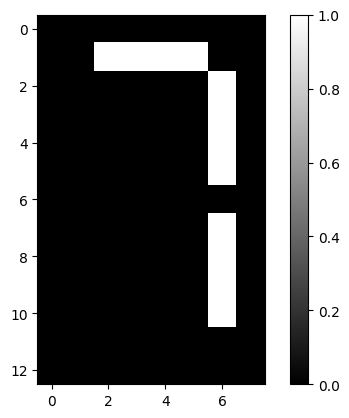

In [ ]:
# Import pyplot
from matplotlib import pyplot as plt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/lcd-digits.csv"
# Read the CSV file, specifying no header
samples = pd.read_csv(url, header=None)

display(samples.head())

# Select the 0th row: digit
digit = samples.iloc[0]

# Print digit
print(digit)

# Reshape digit to a 13x8 array: bitmap
bitmap = digit.values.reshape(13, 8)

# Print bitmap
print(bitmap)

# Use plt.imshow to display bitmap
plt.imshow(bitmap, cmap='gray', interpolation='nearest')
plt.colorbar()
plt.show()

**NMF learns the parts of images**  
Now use what you've learned about NMF to decompose the digits dataset. You are again given the digit images as a 2D array samples. This time, you are also provided with a function show_as_image() that displays the image encoded by any 1D array:

    def show_as_image(sample):
        bitmap = sample.reshape((13, 8))
        plt.figure()
        plt.imshow(bitmap, cmap='gray', interpolation='nearest')
        plt.colorbar()
        plt.show()
After you are done, take a moment to look through the plots and notice how NMF has expressed the digit as a sum of the components!

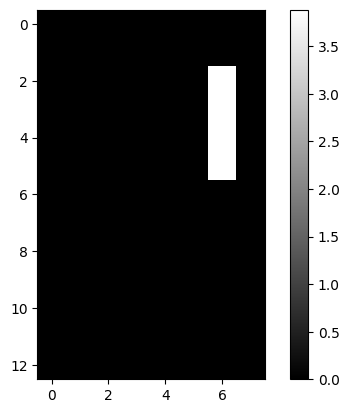

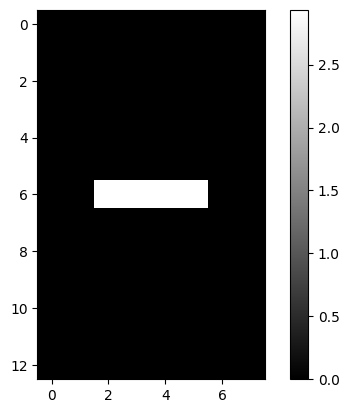

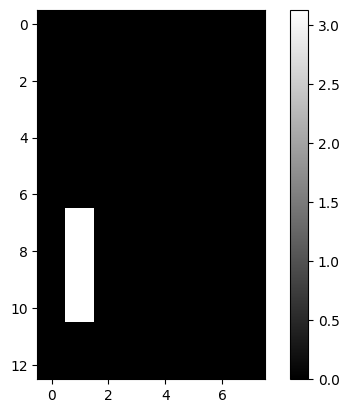

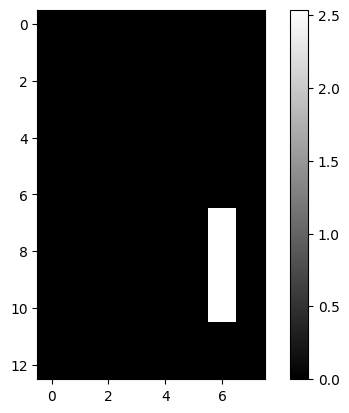

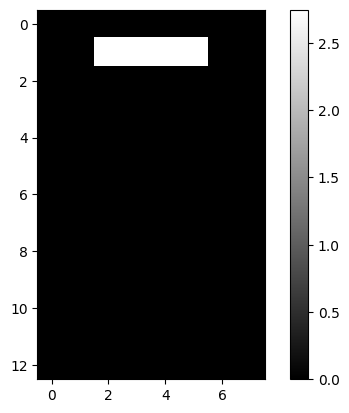

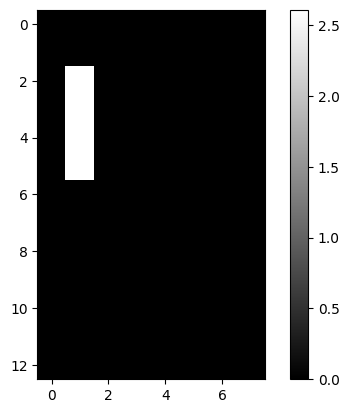

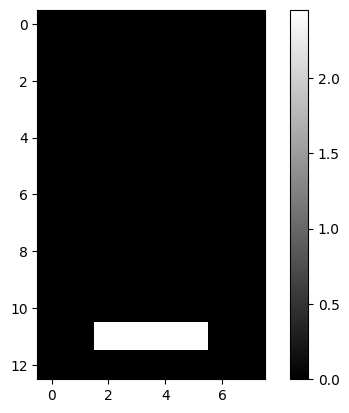

[2.57347960e-01 0.00000000e+00 0.00000000e+00 3.94333376e-01
 3.64045642e-01 0.00000000e+00 3.51281933e-14]


In [ ]:
# Import NMF
from sklearn.decomposition import NMF

# Create an NMF model: model
model = NMF(n_components=7)

# Apply fit_transform to samples: features
features = model.fit_transform(samples)

def show_as_image(sample):
    bitmap = sample.reshape((13, 8))
    plt.figure()

    plt.imshow(bitmap, cmap='gray', interpolation='nearest')
    plt.colorbar()
    plt.show()

# Call show_as_image on each component
for component in model.components_:
    show_as_image(component)

# Select the 0th row of features: digit_features
digit_features = features[0]

# Print digit_features
print(digit_features)

# Take a moment to look through the plots and notice how NMF has expressed the digit as a sum of the components!

**PCA doesn't learn parts**  
Unlike NMF, PCA doesn't learn the parts of things. Its components do not correspond to topics (in the case of documents) or to parts of images, when trained on images. Verify this for yourself by inspecting the components of a PCA model fit to the dataset of LED digit images from the previous exercise. The images are available as a 2D array samples. Also available is a modified version of the show_as_image() function which colors a pixel red if the value is negative.

After submitting the answer, notice that the components of PCA do not represent meaningful parts of images of LED digits!

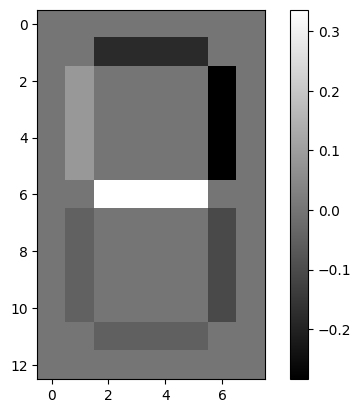

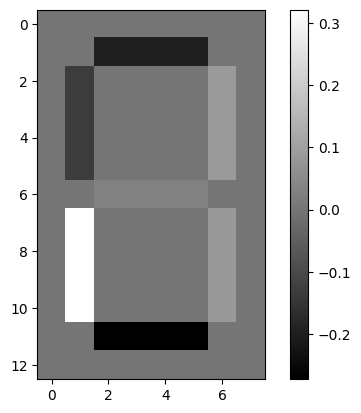

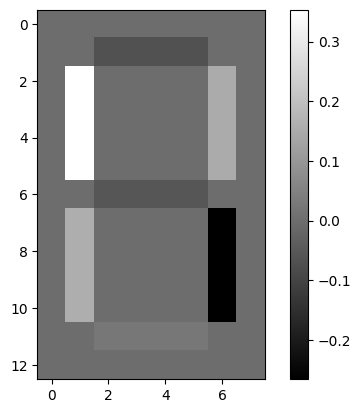

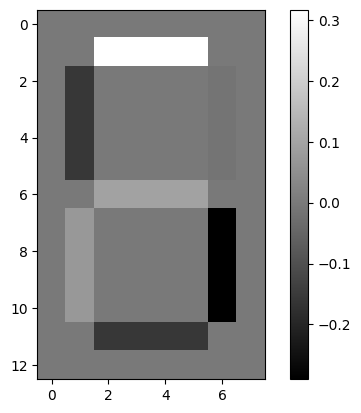

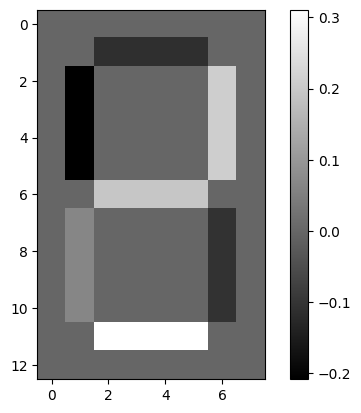

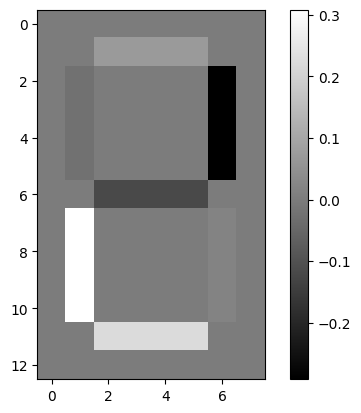

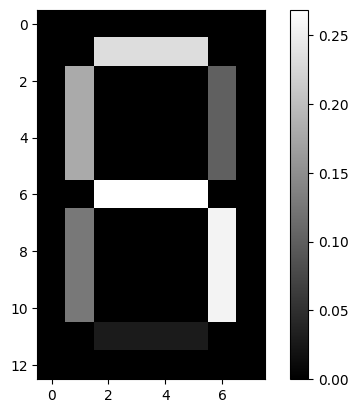

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create a PCA instance: model
model = PCA(n_components = 7)

# Apply fit_transform to samples: features
features = model.fit_transform(samples)

# Call show_as_image on each component
for component in model.components_:
    show_as_image(component)


# Notice that the components of PCA do not represent meaningful parts of images of LED digits!

### Reccomender System

**Which articles are similar to 'Cristiano Ronaldo'?**  
In the video, you learned how to use NMF features and the cosine similarity to find similar articles. Apply this to your NMF model for popular Wikipedia articles, by finding the articles most similar to the article about the footballer Cristiano Ronaldo. The NMF features you obtained earlier are available as nmf_features, while titles is a list of the article titles.

In [ ]:
# Perform the necessary imports
import pandas as pd
from sklearn.preprocessing import normalize

# Normalize the NMF features: norm_features
norm_features = normalize(nmf_features)

# Create a DataFrame: df
df = pd.DataFrame(norm_features, index = titles)

# Select the row corresponding to a valid key from the index (e.g., 'aaron'): article
article = df.loc['aaron']

# Compute the dot products: similarities
similarities = df.dot(article)

# Display those with the largest cosine similarity
print(similarities.nlargest())

# - although you may need to know a little about football (or soccer, depending on where you're from!)
# to be able to evaluate for yourself the quality of the computed similarities!

aaron     1.000000
bowl      0.999806
friday    0.999762
wonder    0.999703
moore     0.999700
dtype: float64


**Recommend musical artists part I**   
In this exercise and the next, you'll use what you've learned about NMF to recommend popular music artists! You are given a sparse array artists whose rows correspond to artists and whose columns correspond to users. The entries give the number of times each artist was listened to by each user.

In this exercise, build a pipeline and transform the array into normalized NMF features. The first step in the pipeline, MaxAbsScaler, transforms the data so that all users have the same influence on the model, regardless of how many different artists they've listened to. In the next exercise, you'll use the resulting normalized NMF features for recommendation!

- Import:
  -  NMF from sklearn.decomposition.
  - Normalizer and MaxAbsScaler from sklearn.preprocessing.
  - make_pipeline from sklearn.pipeline.
- Create an instance of MaxAbsScaler called scaler.
- Create an NMF instance with 20 components called nmf.
- Create an instance of Normalizer called normalizer.
- Create a pipeline called pipeline that chains together scaler, nmf, and normalizer.
- Apply the .fit_transform() method of pipeline to artists. Assign the result to norm_features.

In [ ]:
# Perform the necessary imports
from sklearn.decomposition import NMF
from sklearn.preprocessing import Normalizer, MaxAbsScaler
from sklearn.pipeline import make_pipeline
from scipy.sparse import csr_matrix

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Musical%20artists/scrobbler-small-sample.csv"
# Read the CSV file
artists_playcounts = pd.read_csv(url)

display(artists_playcounts.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Musical%20artists/artists.csv"
# Read the CSV file, specifying no header
artist_names = pd.read_csv(url, header=None)

display(artist_names.head())


# Create a MaxAbsScaler: scaler
scaler = MaxAbsScaler()

# Create an NMF model: nmf
nmf = NMF(n_components = 20)

# Create a Normalizer: normalizer
normalizer = Normalizer()

# Create a pipeline: pipeline
pipeline = make_pipeline(scaler, nmf, normalizer)

# Apply fit_transform to the artist playcounts data to get features for each artist
# We need to reshape the data to have artists as rows and users as columns
# First, let's create a pivot table
pivot_table = artists_playcounts.pivot_table(index='artist_offset', columns='user_offset', values='playcount', fill_value=0)

data = pd.crosstab(artists_playcounts['artist_offset'], artists_playcounts['user_offset'], values=artists_playcounts['playcount'], aggfunc='sum').fillna(0)

# Convert the dense DataFrame to a sparse matrix
sparse_data = csr_matrix(data)

# Apply the pipeline to the sparse matrix
norm_features = pipeline.fit_transform(sparse_data)

print(sparse_data)
print(norm_features)

# now that you've computed the normalized NMF features, you'll use them in the next exercise to recommend musical artists!

,user_offset,artist_offset,playcount
0,1,79,58
1,1,84,80
2,1,86,317
3,1,89,64
4,1,96,159


,0
0,Massive Attack
1,Sublime
2,Beastie Boys
3,Neil Young
4,Dead Kennedys


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2894 stored elements and shape (111, 500)>
  Coords	Values
  (0, 2)	105.0
  (0, 15)	165.0
  (0, 20)	91.0
  (0, 21)	98.0
  (0, 29)	120.0
  (0, 48)	236.0
  (0, 70)	67.0
  (0, 95)	77.0
  (0, 96)	93.0
  (0, 109)	98.0
  (0, 113)	63.0
  (0, 126)	63.0
  (0, 127)	429.0
  (0, 130)	151.0
  (0, 132)	103.0
  (0, 152)	83.0
  (0, 153)	65.0
  (0, 162)	54.0
  (0, 181)	456.0
  (0, 183)	592.0
  (0, 186)	111.0
  (0, 193)	158.0
  (0, 194)	53.0
  (0, 195)	216.0
  (0, 201)	89.0
  :	:
  (109, 444)	82.0
  (109, 450)	271.0
  (109, 467)	107.0
  (109, 472)	130.0
  (109, 478)	776.0
  (109, 483)	66.0
  (109, 498)	55.0
  (110, 56)	51.0
  (110, 60)	272.0
  (110, 119)	156.0
  (110, 149)	87.0
  (110, 165)	112.0
  (110, 291)	104.0
  (110, 325)	183.0
  (110, 345)	106.0
  (110, 358)	80.0
  (110, 360)	111.0
  (110, 361)	57.0
  (110, 414)	92.0
  (110, 429)	60.0
  (110, 433)	388.0
  (110, 460)	66.0
  (110, 463)	105.0
  (110, 465)	128.0
  (110, 468)	69.0
[[0.     

**Recommend musical artists part II**  
Suppose you were a big fan of Bruce Springsteen - which other musical artists might you like? Use your NMF features from the previous exercise and the cosine similarity to find similar musical artists. A solution to the previous exercise has been run, so norm_features is an array containing the normalized NMF features as rows. The names of the musical artists are available as the list artist_names.

In [ ]:
# Import pandas
import pandas as pd

# Set the first column of artist_names as the index
artist_names = artist_names.set_index(0)

# Create a DataFrame: df
df = pd.DataFrame(norm_features, index = artist_names.index)

# Select row of 'Bruce Springsteen': artist
artist = df.loc["Bruce Springsteen"]

# Compute cosine similarities: similarities
similarities = df.dot(artist)

# Display those with highest cosine similarity
print(similarities.nlargest())

0
Bruce Springsteen    1.000000
Leonard Cohen        0.959486
Neil Young           0.948808
The Beach Boys       0.856939
Van Morrison         0.830922
dtype: float64
